# ResNet-50 (Partial Unfreeze — layer4[2] only)

## Changes from Partial Unfreeze (02)

| | 02. layer4 unfreeze | 03. layer4[2] only |
|---|---|---|
| Unfrozen layers | All of `layer4` (3 bottleneck blocks) | Only `layer4[2]` (last bottleneck block) |
| Trainable params | ~15M | ~4.7M |
| LR — unfrozen block | 1e-4 | 1e-4 |
| LR — FC head | 1e-3 | 1e-3 |
| Weight decay | 1e-4 | 1e-4 |
| Dropout | 0.5 | 0.5 |
| Epochs | 30 | 30 |

## Rationale

The full `layer4` unfreeze (02) showed meaningful gains in AUC-ROC (0.829 → 0.880) but heavy overfitting — train/val F2 gap of 0.24 by epoch 30, with val loss diverging from epoch 5.

The root cause is a param-to-data ratio problem: 15M trainable parameters against ~8K training images is too high. The fix is to narrow the unfreeze scope rather than fight it with regularisation.

`layer4` in ResNet-50 has three bottleneck blocks (`layer4[0]`, `layer4[1]`, `layer4[2]`). The **last block** (`layer4[2]`) is the most semantically specific — it directly feeds the global average pooling before the classifier. Unfreezing only this block adapts the highest-level features while freezing the earlier two blocks that learn more general representations.

Reducing trainable params from 15M to ~4.7M brings the param-to-data ratio down to a level comparable to what worked well in the penalty experiments (EfficientNet-B0 partial unfreeze).

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

from src.data.dataset import HAM10000Dataset
from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.resnet import get_resnet50
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

In [2]:
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [3]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
train_dataset = HAM10000Dataset(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    transform=get_augmented_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)

_, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=224,
    num_workers=4,
)

train_df    = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

Positive weight: tensor([8.1117], device='cuda:0')


In [5]:
model = get_resnet50(num_classes=1, freeze_backbone=True, dropout=0.5).to(device)

# Only unfreeze the last bottleneck block of layer4
for param in model.layer4[2].parameters():
    param.requires_grad = True

optimizer = optim.AdamW([
    {'params': model.layer4[2].parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(),        'lr': 1e-3},
], weight_decay=1e-4)

criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 30
scheduler  = CosineAnnealingLR(optimizer, T_max=num_epochs)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')

Trainable params: 4,464,641 / 23,510,081


In [6]:
best_val_f2 = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics   = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step()

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, "
        f"Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, "
        f"Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        torch.save(model.state_dict(), ROOT / 'models/resnet50_layer4_2_best.pth')
        print(f'  -> Saved best model (val F2: {best_val_f2:.4f})')

Epoch [1/30] | Train Loss: 1.0159, Bal Acc: 0.6896, Recall: 0.7149, F2: 0.4806 | Val Loss: 0.9179, Bal Acc: 0.7320, Recall: 0.8644, F2: 0.5472
  -> Saved best model (val F2: 0.5472)


Epoch [2/30] | Train Loss: 0.8796, Bal Acc: 0.7551, Recall: 0.8187, F2: 0.5592 | Val Loss: 0.8770, Bal Acc: 0.7498, Recall: 0.8771, F2: 0.5668
  -> Saved best model (val F2: 0.5668)


Epoch [3/30] | Train Loss: 0.8398, Bal Acc: 0.7675, Recall: 0.8369, F2: 0.5743 | Val Loss: 0.8822, Bal Acc: 0.7437, Recall: 0.7161, F2: 0.5552


Epoch [4/30] | Train Loss: 0.8147, Bal Acc: 0.7755, Recall: 0.8187, F2: 0.5855 | Val Loss: 0.8849, Bal Acc: 0.7599, Recall: 0.7373, F2: 0.5773
  -> Saved best model (val F2: 0.5773)


Epoch [5/30] | Train Loss: 0.8113, Bal Acc: 0.7757, Recall: 0.8096, F2: 0.5864 | Val Loss: 0.8685, Bal Acc: 0.7575, Recall: 0.7415, F2: 0.5741


...

Epoch [26/30] | Train Loss: 0.6221, Bal Acc: 0.8317, Recall: 0.8563, F2: 0.6668 | Val Loss: 0.9530, Bal Acc: 0.7731, Recall: 0.7542, F2: 0.5957


Epoch [27/30] | Train Loss: 0.6098, Bal Acc: 0.8505, Recall: 0.8883, F2: 0.6932 | Val Loss: 0.9090, Bal Acc: 0.7718, Recall: 0.7415, F2: 0.5940


Epoch [28/30] | Train Loss: 0.6248, Bal Acc: 0.8445, Recall: 0.8689, F2: 0.6866 | Val Loss: 0.9593, Bal Acc: 0.7645, Recall: 0.7415, F2: 0.5837


Epoch [29/30] | Train Loss: 0.6421, Bal Acc: 0.8359, Recall: 0.8620, F2: 0.6730 | Val Loss: 0.9371, Bal Acc: 0.7651, Recall: 0.7415, F2: 0.5845


Epoch [30/30] | Train Loss: 0.6184, Bal Acc: 0.8364, Recall: 0.8643, F2: 0.6733 | Val Loss: 0.9966, Bal Acc: 0.7629, Recall: 0.7288, F2: 0.5815


## Training Curves

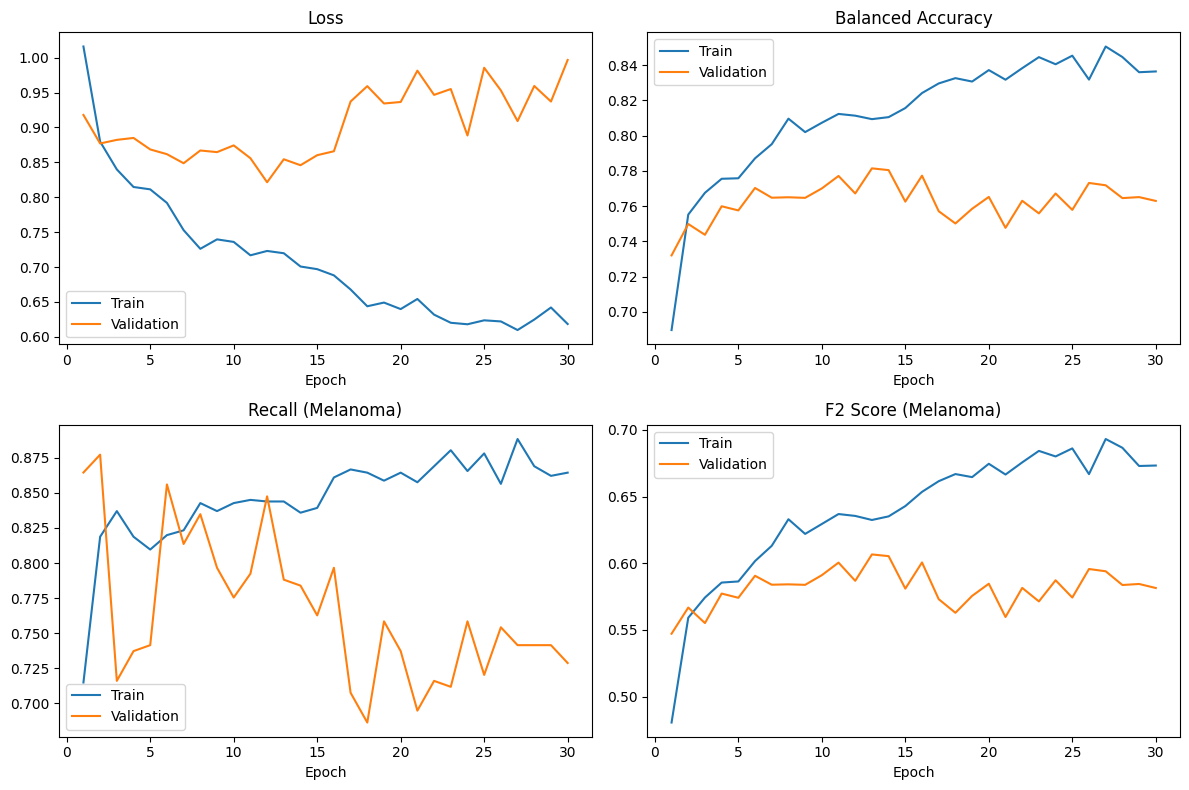

In [7]:
plot_training_curves(train_history, val_history)

## Threshold Tuning

In [8]:
model.load_state_dict(torch.load(str(ROOT / 'models/resnet50_layer4_2_best.pth'), map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

Best threshold: 0.48 | Val F2: 0.6073


## Test Set Evaluation

Threshold:          0.48
AUC-ROC:            0.8678
Balanced Accuracy:  0.7798
F2 Score:           0.5986

              precision    recall  f1-score   support

Non-Melanoma     0.9669    0.7642    0.8537      1340
    Melanoma     0.3009    0.7953    0.4366       171

    accuracy                         0.7677      1511
   macro avg     0.6339    0.7798    0.6451      1511
weighted avg     0.8916    0.7677    0.8065      1511



c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


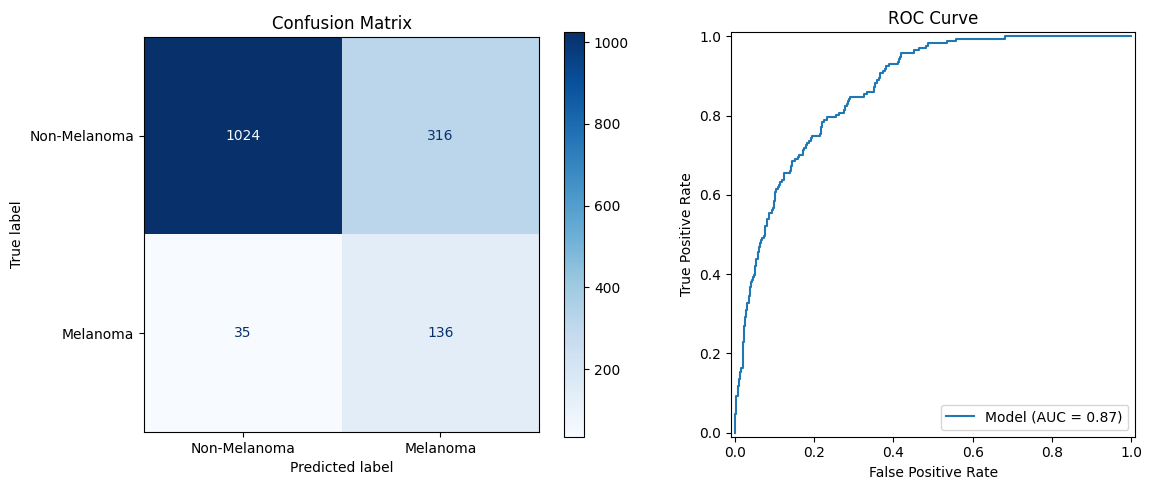

: 

In [ ]:
evaluate_model(model, test_loader, device, threshold=best_threshold)